# 04 Calibration and threshold selection

**Purpose.** Show protocol steps 2-3 (`docs/plan.md` Phase 3) for the champion (LightGBM, v2
features, `src/fraud/models/train.py`): calibrate the raw score into a probability on validation,
then pick the decision threshold from the validation precision-recall curve at precision >= 0.50.
Both happen automatically in `fraud.models.estimator.CalibratedThresholdClassifier`; this notebook
loads the already-fitted champion and its saved outputs to show what that produced.

In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from fraud.data.paths import PROCESSED_DIR
from fraud.features.pipeline import transform_with_context
from fraud.models.train import MODEL_PATH
from fraud.params import REPO_ROOT, load_params

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e1"
LEGIT, FRAUD, ACCENT = "#2a78d6", "#eb6834", "#3c9a5f"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "text.color": INK,
        "axes.labelcolor": INK,
        "xtick.color": INK2,
        "ytick.color": INK2,
        "axes.edgecolor": GRID,
        "grid.color": GRID,
        "font.size": 11,
    }
)

params = load_params()
model_cfg = params["model"]
pipeline = joblib.load(MODEL_PATH)
feature_pipeline = pipeline.named_steps["features"]
model = pipeline.named_steps["model"]
print(
    "step:",
    model_cfg["step"],
    "| feature_set:",
    model_cfg["feature_set"],
    "| calibration:",
    model_cfg["calibration"],
)
print("threshold:", model.threshold_)

C:\Users\ilian\VS Code Projects\credit-card-fraud-detector\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026/09/28 14:48:29 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at C:\Users\ilian\VS Code Projects\credit-card-fraud-detector\.venv\Lib\site-packages\mlflow\assistant\skills\instrumenting-with-mlflow-tracing\SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


step: lightgbm | feature_set: v2 | calibration: sigmoid
threshold: 0.0003052068202174992


## 1. The validation precision-recall curve and the chosen operating point

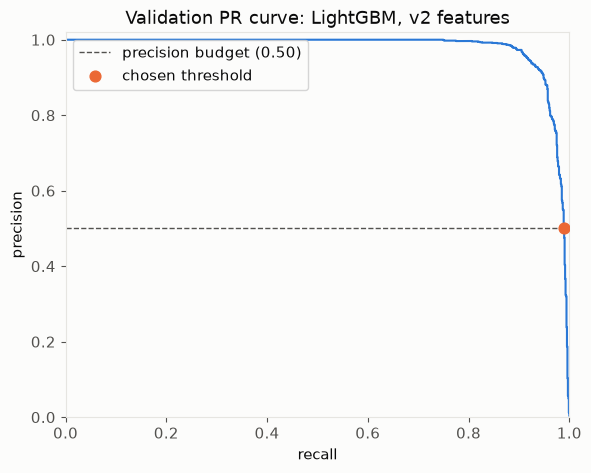

chosen operating point: recall=0.9898, precision=0.5000


In [2]:
curve = json.loads((REPO_ROOT / "reports" / "pr_curve.json").read_text())
precision, recall = np.array(curve["precision"]), np.array(curve["recall"])
train_metrics = json.loads((REPO_ROOT / "reports" / "train_metrics.json").read_text())

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot(recall, precision, color=LEGIT, linewidth=1.5)
ax.axhline(
    model_cfg["min_precision"],
    color=INK2,
    linestyle="--",
    linewidth=1,
    label="precision budget (0.50)",
)
ax.scatter(
    [train_metrics["recall"]],
    [train_metrics["precision"]],
    color=FRAUD,
    s=60,
    zorder=5,
    label="chosen threshold",
)
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Validation PR curve: LightGBM, v2 features")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend()
plt.show()

print(
    f"chosen operating point: recall={train_metrics['recall']:.4f}, precision={train_metrics['precision']:.4f}"
)

## 2. What the threshold means in practice: how many transactions get flagged

In [3]:
train_df = pd.read_parquet(PROCESSED_DIR / "train.parquet")
valid_df = pd.read_parquet(PROCESSED_DIR / "valid.parquet")
X_valid = transform_with_context(feature_pipeline, valid_df, context=train_df)
score = model.predict_proba(X_valid)[:, 1]
flagged = (score >= model.threshold_).mean()
print(f"threshold (calibrated probability): {model.threshold_:.6f}")
print(f"share of validation transactions flagged: {flagged * 100:.3f}%")
print(f"validation fraud rate: {valid_df['is_fraud'].mean() * 100:.3f}%")

threshold (calibrated probability): 0.000305
share of validation transactions flagged: 0.872%
validation fraud rate: 0.441%


## 3. Calibration check: does the predicted probability match the empirical fraud rate?

,bin,n,mean_predicted,empirical_fraud_rate
0,0,24414,0.000300,0.000000
1,1,24414,0.000300,0.000000
2,2,24414,0.000300,0.000000
3,3,24414,0.000300,0.000000
4,4,24414,0.000300,0.000000
5,5,24414,0.000300,0.000000
6,6,24414,0.000300,0.000041
7,7,24414,0.000300,0.000000
8,8,24414,0.000300,0.000000
9,9,24414,0.040713,0.044032


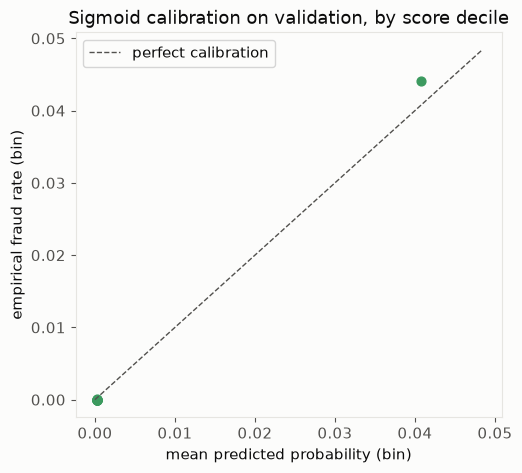

In [4]:
valid_y = valid_df["is_fraud"].to_numpy()
bins = np.quantile(score, np.linspace(0, 1, 11))
bins[-1] += 1e-12
bin_idx = np.digitize(score, bins[1:-1])
rows = []
for b in range(10):
    mask = bin_idx == b
    if mask.sum() == 0:
        continue
    rows.append(
        {
            "bin": b,
            "n": int(mask.sum()),
            "mean_predicted": float(score[mask].mean()),
            "empirical_fraud_rate": float(valid_y[mask].mean()),
        }
    )
calib = pd.DataFrame(rows)
display(calib)

fig, ax = plt.subplots(figsize=(5.5, 5))
lim = max(calib["mean_predicted"].max(), calib["empirical_fraud_rate"].max()) * 1.1
ax.plot([0, lim], [0, lim], color=INK2, linestyle="--", linewidth=1, label="perfect calibration")
ax.scatter(calib["mean_predicted"], calib["empirical_fraud_rate"], color=ACCENT, s=40)
ax.set_xlabel("mean predicted probability (bin)")
ax.set_ylabel("empirical fraud rate (bin)")
ax.set_title("Sigmoid calibration on validation, by score decile")
ax.legend()
plt.show()

## 4. Conclusions

**The threshold sits at a very low absolute probability** (~0.0003), which looks strange until you
remember the validation fraud rate is only 0.44%: even a well-calibrated model puts most of its
probability mass near zero, and the top decile of scores is where almost all of the signal lives.
In relative terms the threshold is meaningful — it flags a small, targeted slice of validation
traffic while catching 99% of its fraud.

**About 0.87% of validation transactions are flagged** (2,130 of 244,140: 1,065 true positives plus
1,065 false positives), for a recall of 0.990 at precision 0.50 — exactly one false alarm per fraud
caught, the CLAUDE.md budget met on the nose. That is a large improvement over the v1 XGBoost
candidate (`03_models.ipynb`), which needed a worse recall/false-alarm trade-off to clear the same
precision floor.

**Calibration is essentially flat everywhere except the top decile, and good where it matters.**
The bottom nine deciles all sit at the pipeline's near-zero floor score with an empirical fraud rate
indistinguishable from 0 (one decile has a single fraud in 24,414 rows) — there simply isn't enough
separation among low scores to calibrate finely, because fraud is concentrated at the very top of
the score distribution. In the top decile, where the signal actually lives, calibration is close:
mean predicted probability 0.041 vs empirical fraud rate 0.044. This is the region the decision
threshold sits deep inside, so the calibration that matters for this system's actual operating point
looks trustworthy.